In [2]:
"""斯坦福大学近期对一门计算机课的全体学生要求：禁止手写一行代码，
all in AI，朱浩（学号23123095）将尝试类似的努力
对话链接：https://chatgpt.com/share/693256b2-dc44-8005-8d38-4a6acf1f970f
"""

'斯坦福大学近期对一门计算机课的全体学生要求：禁止手写一行代码，all in AI，朱浩（学号23123095）将尝试类似的努力'

In [3]:
"""根据需求（"利用双原子的L-J势函数产生能量-距离的数据点。然后选取原子间距离（或其他物理化学性质）作为特征，利用任意一种或多种机器学习方法（核函数方法或深度神经元网络方法）构建机器学习模型进行预测，与解析表达式结果的误差评估（R2，MAE和RMSE等）。对原始数据加上高斯微扰作为误差函数，重新构建机器学习模型进行预测。讨论高斯函数半高宽对机器学习预测精度的影响。"）任务拆解：+ 每一步要做什么 + 要输出什么"""

'根据需求（"利用双原子的L-J势函数产生能量-距离的数据点。然后选取原子间距离（或其他物理化学性质）作为特征，利用任意一种或多种机器学习方法（核函数方法或深度神经元网络方法）构建机器学习模型进行预测，与解析表达式结果的误差评估（R2，MAE和RMSE等）。对原始数据加上高斯微扰作为误差函数，重新构建机器学习模型进行预测。讨论高斯函数半高宽对机器学习预测精度的影响。"）任务拆解：+ 每一步要做什么 + 要输出什么'

In [4]:
"""details：
1.生成 LJ 势能数据

2.选择特征

3.选择 ML 模型（SVR/NN）

4.分割数据并训练模型

5.计算评价指标（R²、MAE、RMSE）

6.添加高斯噪声（不同半宽）

7.重新训练模型

8.绘制噪声 vs 指标的趋势图

9.结果讨论

10.撰写报告
"""

'details：\n1.生成 LJ 势能数据\n\n2.选择特征\n\n3.选择 ML 模型（SVR/NN）\n\n4.分割数据并训练模型\n\n5.计算评价指标（R²、MAE、RMSE）\n\n6.添加高斯噪声（不同半宽）\n\n7.重新训练模型\n\n8.绘制噪声 vs 指标的趋势图\n\n9.结果讨论\n\n10.撰写报告\n'

          r          V
0  0.800000  42.948872
1  0.804409  39.728843
2  0.808818  36.745679
3  0.813226  33.981354
4  0.817635  31.419281


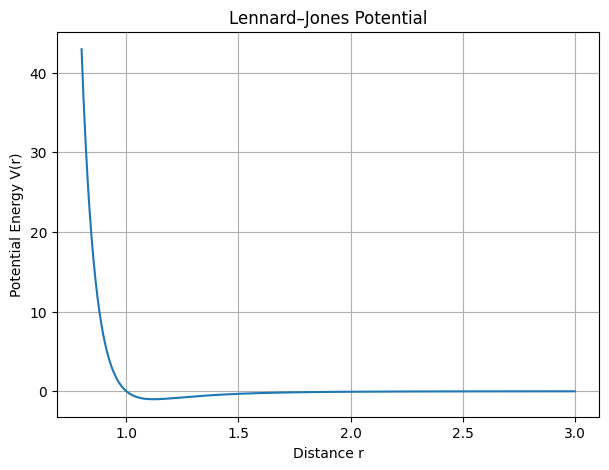

In [1]:
#1.生成L-J数据
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 1. Lennard-Jones potential
# -----------------------
def LJ(r, epsilon=1.0, sigma=1.0):
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

# -----------------------
# 2. Generate distance data
# -----------------------
# You may choose any range. Here typical LJ range:
r_min = 0.8   # avoid r=0 (infinite energy)
r_max = 3.0
num_points = 500

r_values = np.linspace(r_min, r_max, num_points)
V_values = LJ(r_values)

# -----------------------
# 3. Put into DataFrame
# -----------------------
df = pd.DataFrame({
    "r": r_values,
    "V": V_values
})

print(df.head())

# -----------------------
# 4. Visualization
# -----------------------
plt.figure(figsize=(7,5))
plt.plot(r_values, V_values)
plt.xlabel("Distance r")
plt.ylabel("Potential Energy V(r)")
plt.title("Lennard–Jones Potential")
plt.grid(True)
plt.show()


In [ ]:
#Part 2：构建机器学习模型
"""具体要求：
a.选择特征

b.选择 ML 模型（SVR/NN）

c.分割数据并训练模型
"""

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# X = distance r (2D shape needed for sklearn)
X = df["r"].values.reshape(-1, 1)
y = df["V"].values


在 Colab 中安装 Python 库，您可以在代码单元格中使用 `!pip install` 命令。例如，要安装名为 `library_name` 的库，您可以运行以下命令：

In [6]:
# 替换 'library_name' 为您要安装的库的实际名称
!pip install library_name

ERROR: Could not find a version that satisfies the requirement library_name (from versions: none)
ERROR: No matching distribution found for library_name


请注意，`!` 符号告诉 Colab 在系统 shell 中执行该命令，而不是作为 Python 代码。安装完成后，您就可以在其他代码单元格中导入并使用该库了。

In [7]:
from sklearn.svm import SVR

svr_model = SVR(kernel="rbf", C=100, gamma="scale")
svr_model.fit(X, y)

y_pred_svr = svr_model.predict(X)


In [8]:
from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation='relu',
    solver='adam',
    max_iter=5000,
    random_state=0
)
mlp_model.fit(X, y)

y_pred_mlp = mlp_model.predict(X)


In [9]:
def evaluate(true, pred, name="Model"):
    R2 = r2_score(true, pred)
    MAE = mean_absolute_error(true, pred)
    RMSE = np.sqrt(mean_squared_error(true, pred))

    print(f"\n{name} Performance:")
    print(f"R²   = {R2:.6f}")
    print(f"MAE  = {MAE:.6f}")
    print(f"RMSE = {RMSE:.6f}")


In [10]:
evaluate(y, y_pred_svr, "SVR")
evaluate(y, y_pred_mlp, "MLP Neural Network")



SVR Performance:
R²   = 0.779801
MAE  = 0.539231
RMSE = 2.316862

MLP Neural Network Performance:
R²   = 0.981222
MAE  = 0.232930
RMSE = 0.676573


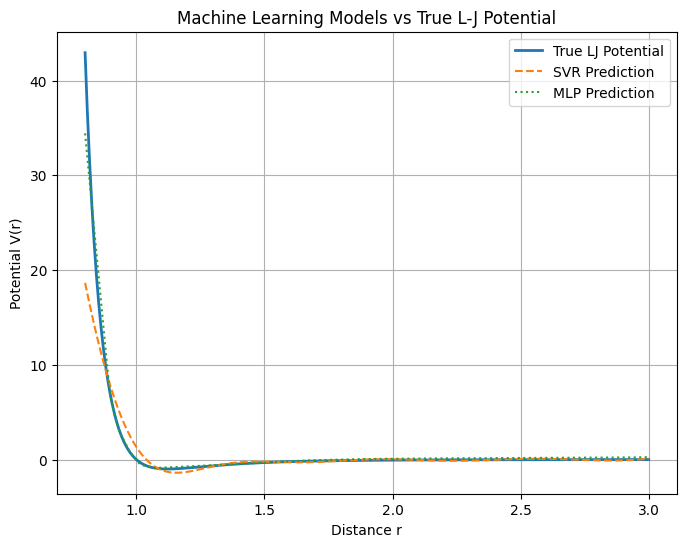

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(X, y, label="True LJ Potential", linewidth=2)
plt.plot(X, y_pred_svr, label="SVR Prediction", linestyle="--")
plt.plot(X, y_pred_mlp, label="MLP Prediction", linestyle=":")
plt.xlabel("Distance r")
plt.ylabel("Potential V(r)")
plt.title("Machine Learning Models vs True L-J Potential")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#Part 3：加入高斯噪声
"""具体要求：
a.添加高斯微扰作为误差函数

b.重新训练模型

c.绘制噪声 vs 指标的趋势图
"""

In [12]:
noise_levels = [0, 0.01, 0.05, 0.1, 0.2]


In [13]:
def add_noise(V, sigma):
    noise = np.random.normal(0, sigma, size=len(V))
    return V + noise


In [14]:
results = []

for sigma in noise_levels:
    print(f"\n========= Noise sigma = {sigma} ==========")

    # ---- Add noise ----
    y_noisy = add_noise(y, sigma)

    # ---- Train SVR ----
    svr_model = SVR(kernel="rbf", C=100, gamma="scale")
    svr_model.fit(X, y_noisy)
    y_pred_svr = svr_model.predict(X)

    # ---- Train MLP ----
    mlp_model = MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        solver='adam',
        max_iter=5000,
    )
    mlp_model.fit(X, y_noisy)
    y_pred_mlp = mlp_model.predict(X)

    # ---- Evaluate both models ----
    R2_svr = r2_score(y, y_pred_svr)
    MAE_svr = mean_absolute_error(y, y_pred_svr)
    RMSE_svr = np.sqrt(mean_squared_error(y, y_pred_svr))

    R2_mlp = r2_score(y, y_pred_mlp)
    MAE_mlp = mean_absolute_error(y, y_pred_mlp)
    RMSE_mlp = np.sqrt(mean_squared_error(y, y_pred_mlp))

    results.append([sigma, R2_svr, MAE_svr, RMSE_svr, R2_mlp, MAE_mlp, RMSE_mlp])



========= Noise sigma = 0 ==========

========= Noise sigma = 0.01 ==========

========= Noise sigma = 0.05 ==========

========= Noise sigma = 0.1 ==========

========= Noise sigma = 0.2 ==========


In [15]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Noise σ",
        "SVR_R²", "SVR_MAE", "SVR_RMSE",
        "MLP_R²", "MLP_MAE", "MLP_RMSE"
    ]
)

print(results_df)


   Noise σ    SVR_R²   SVR_MAE  SVR_RMSE    MLP_R²   MLP_MAE  MLP_RMSE
0     0.00  0.779801  0.539231  2.316862  0.986798  0.229919  0.567296
1     0.01  0.779472  0.537129  2.318594  0.988369  0.216306  0.532486
2     0.05  0.782124  0.525169  2.304606  0.989095  0.168119  0.515599
3     0.10  0.780464  0.522000  2.313370  0.976371  0.272800  0.758960
4     0.20  0.787634  0.524226  2.275281  0.989896  0.219822  0.496296


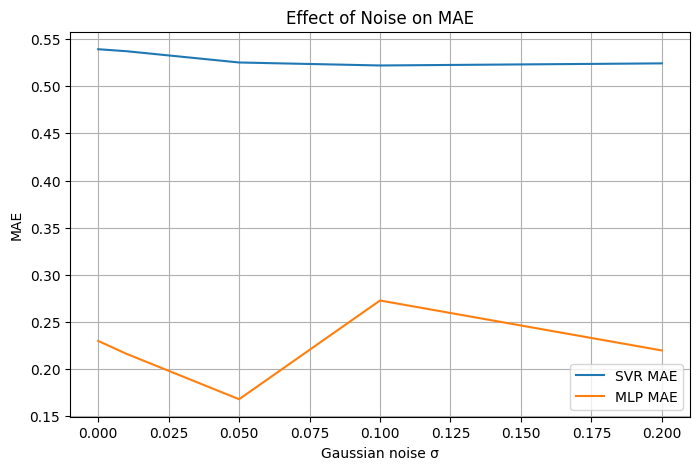

In [16]:
plt.figure(figsize=(8,5))
plt.plot(results_df["Noise σ"], results_df["SVR_MAE"], label="SVR MAE")
plt.plot(results_df["Noise σ"], results_df["MLP_MAE"], label="MLP MAE")
plt.xlabel("Gaussian noise σ")
plt.ylabel("MAE")
plt.title("Effect of Noise on MAE")
plt.grid()
plt.legend()
plt.show()


In [ ]:
#Part 4：研究高斯噪声对预测精度的影响
"""
具体要求：
重新训练模型

绘制噪声 vs 指标的趋势图
"""

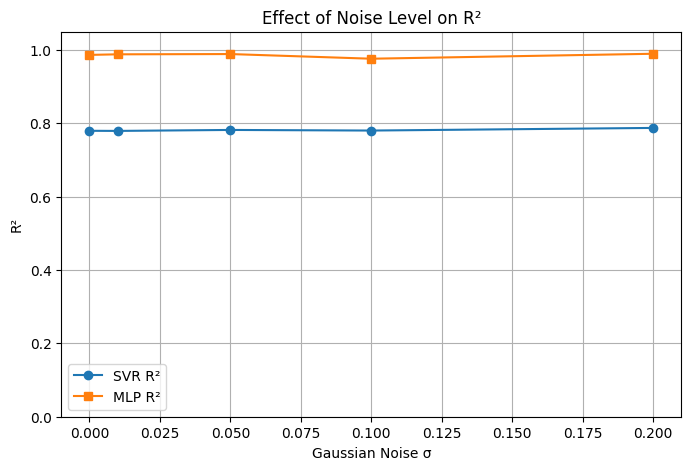

In [17]:
#噪声 vs R²
plt.figure(figsize=(8,5))
plt.plot(results_df["Noise σ"], results_df["SVR_R²"], marker='o', label="SVR R²")
plt.plot(results_df["Noise σ"], results_df["MLP_R²"], marker='s', label="MLP R²")
plt.xlabel("Gaussian Noise σ")
plt.ylabel("R²")
plt.ylim(0,1.05)
plt.title("Effect of Noise Level on R²")
plt.grid(True)
plt.legend()
plt.show()



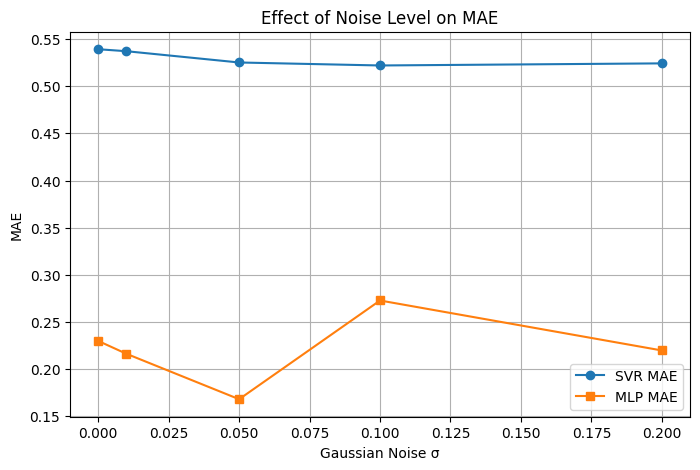

In [18]:
#代码：噪声 vs MAE
plt.figure(figsize=(8,5))
plt.plot(results_df["Noise σ"], results_df["SVR_MAE"], marker='o', label="SVR MAE")
plt.plot(results_df["Noise σ"], results_df["MLP_MAE"], marker='s', label="MLP MAE")
plt.xlabel("Gaussian Noise σ")
plt.ylabel("MAE")
plt.title("Effect of Noise Level on MAE")
plt.grid(True)
plt.legend()
plt.show()


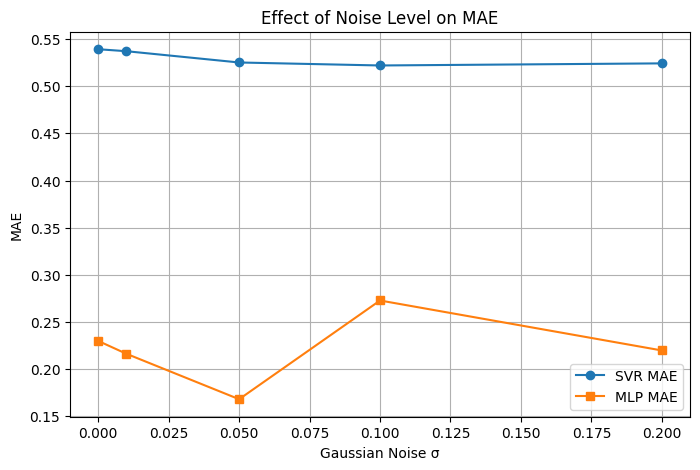

In [19]:
#代码：噪声 vs MAE
plt.figure(figsize=(8,5))
plt.plot(results_df["Noise σ"], results_df["SVR_MAE"], marker='o', label="SVR MAE")
plt.plot(results_df["Noise σ"], results_df["MLP_MAE"], marker='s', label="MLP MAE")
plt.xlabel("Gaussian Noise σ")
plt.ylabel("MAE")
plt.title("Effect of Noise Level on MAE")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
#part5 ：Part 5：结果讨论 / 报告撰写
"""
具体要求：
讨论高斯函数半高宽对机器学习预测精度的影响。
撰写报告
"""